## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [3]:
#1
import pandas as pd

golub = pd.read_csv("/golub.csv")

golub["target"] = golub["cancer"].map({
    "allB": 0,
    "allT": 0,
    "aml": 1
})

golub["target"].value_counts()

,count
target,
0,47
1,25


In [4]:
#2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = golub.drop(columns=["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"])
y = golub["target"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)

print(mse)

1.2522824482837894e-30


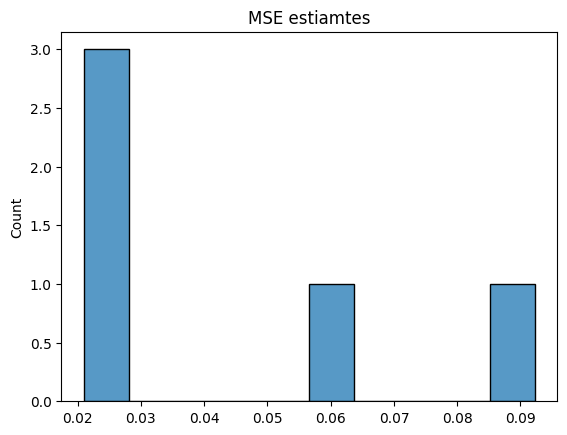

Fold scores: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean score: 0.04336595898622785
Median score: 0.024419803797537328
Std dev: 0.028107820694269984


In [8]:
#3
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

kfold = KFold(n_splits=5, shuffle=True, random_state=100) # Create folds
scores = cross_val_score( # Conduct kfcv:
    model,X,y, # Model and data
    cv=kfold, # Folds
    scoring='neg_mean_squared_error' # Loss function
)

mse = -scores

sns.histplot(mse,bins=10).set(title='MSE estiamtes')
plt.show()

print("Fold scores:", mse)
print("Mean score:", np.mean(mse))
print("Median score:", np.median(mse))
print("Std dev:", np.std(mse))

The linear regression model on the training set achieved a  MSE of approximately `1.25e-30`, which is practically zero. This is because the model has far more predictors and observations and the model can fit the training data quite well. The model has enough parameters to learn every data point perfectly, leading to very low training error (low bias).

However, the cross-validated MSE (from cell #3) shows a mean MSE of approximately `0.043`. This value is significantly higher than the training MSE, indicating that the model does not generalize well to unseen/test data. This discrepancy is a sign of high variance and overfitting. The model has learned the noise and specific patterns of the training data a bit too closely, making it sensitive to new, slightly different data points. It performs well on the data it has seen but poorly on data it hasn't.

From the perspective of the bias-variance trade-off:
*   **Low Bias (on training data):** The model is flexible enough to capture the relationships in the training data, resulting in near-zero training error.
*   **High Variance:** The model's performance varies significantly when tested on different subsets of data (as seen in the different fold scores of the cross-validation). It is highly sensitive to the specific training set and does not generalize well.

Best alpha: 105.24436668425457
Number of selected genes: 34
Number of discarded genes: 7095

Selected genes:
M63138_at           1.294145e-05
M19507_at           1.150747e-05
U05255_s_at         1.146583e-05
M27891_at           1.000528e-05
X17042_at           8.734762e-06
Y00787_s_at         5.454046e-06
M96326_rna1_at      3.045484e-06
M17733_at          -3.027364e-06
J04164_at          -2.975928e-06
M91036_rna1_at      2.704303e-06
X78992_at           2.598685e-06
L06797_s_at        -2.527830e-06
M26602_at          -2.373871e-06
HG3549-HT3751_at   -1.866398e-06
M14328_s_at         1.777423e-06
M14483_rna1_s_at   -1.758451e-06
V00594_s_at        -1.685259e-06
U14968_at           1.377602e-06
Z70759_at           1.289107e-06
X57351_s_at        -1.190599e-06
M11722_at          -1.175811e-06
M33680_at          -1.070980e-06
M11147_at           9.651806e-07
L38941_at           9.359366e-07
HG2887-HT3031_at   -8.149813e-07
X03689_s_at        -7.578508e-07
M26708_s_at        -7.132857e-07


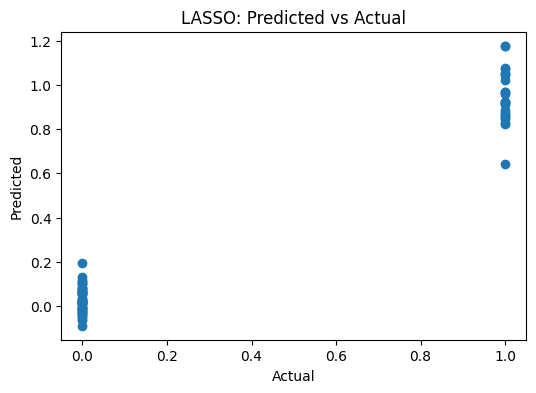

In [ ]:
#4
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt
import numpy as np

# X and Y values from above:
# X = golub.drop(columns=[...])
# y = golub["target"]

# Fit cross-validated LASSO
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X, y)

# Predictions
y_pred_lasso = lasso.predict(X)

# Find selected genes (nonzero coefficients)
coef_series = pd.Series(lasso.coef_, index=X.columns)
selected_genes = coef_series[coef_series != 0].sort_values(key=np.abs, ascending=False)

# Count discarded genes
num_selected = (lasso.coef_ != 0).sum()
num_discarded = X.shape[1] - num_selected

print("Best alpha:", lasso.alpha_)
print("Number of selected genes:", num_selected)
print("Number of discarded genes:", num_discarded)
print("\nSelected genes:")
print(selected_genes)

# Scatterplot of predicted vs actual
plt.figure(figsize=(6,4))
plt.scatter(y, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO: Predicted vs Actual")
plt.show()

Cross-validated LASSO was used to select a subset of predictive genes from the high-dimensional dataset. The model selected 34 genes and discarded 7095 genes by minimizing their coefficients to zero. The selected genes include M63138_at, M19507_at, U05255_s_at, M27891_at, and X17042_at, among others. This demonstrates that only a small subset of genes is necessary for predicting leukemia type, while the majority of genes do not contribute significantly. The scatterplot of predicted versus actual values shows that the model is able to distinguish between the two classes reasonably well, with predictions clustering near 0 and 1.